In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

STINTS SELECCIONADOS
  SOFT | Spa-Francorchamps | TSU | Stint 2 | 28 vueltas
MEDIUM | Monaco          | RUS | Stint 2 | 76 vueltas
  HARD | Monaco          | SAI | Stint 2 | 76 vueltas


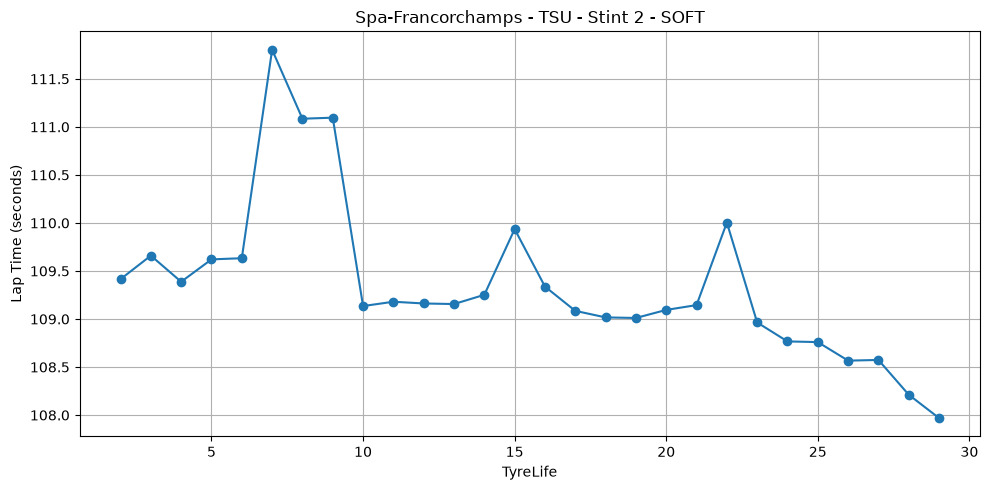

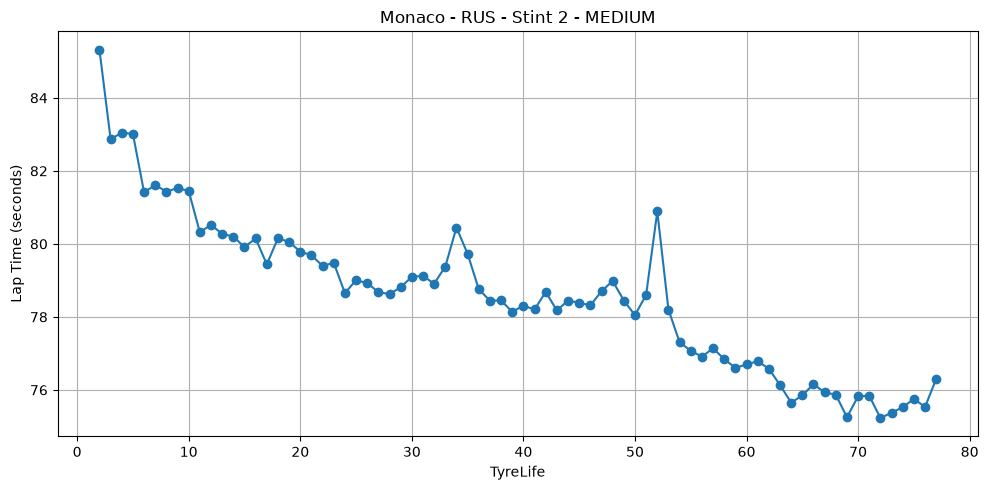

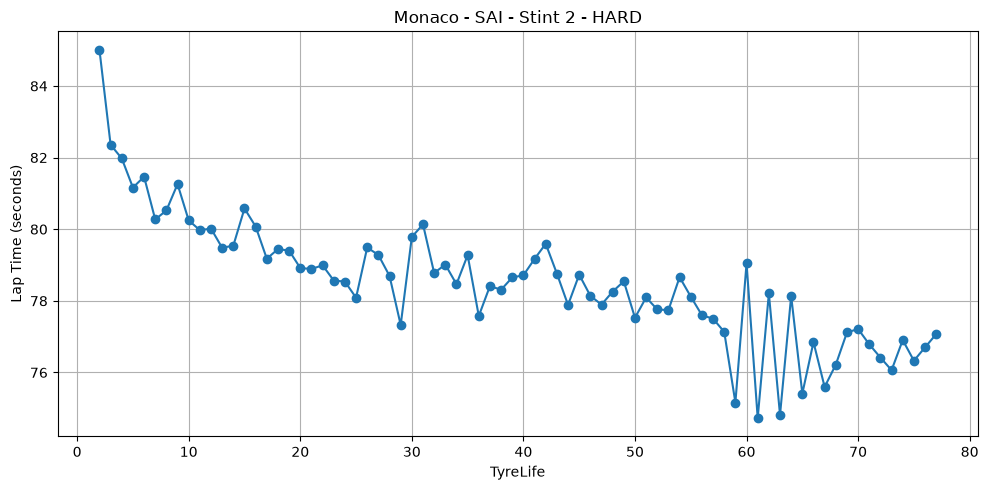

In [2]:
INPUT_PATH = Path("data/processed/stint_laps_2024.parquet")


def plot_stint(df, race, driver, stint):
    data = df[
        (df["Race"] == race)
        & (df["Driver"] == driver)
        & (df["Stint"] == stint)
    ].copy()

    if data.empty:
        print(f"No se encontró: {race} - {driver} - Stint {stint}")
        return

    data = data.sort_values("TyreLife")

    compound = data["Compound"].iloc[0]

    plt.figure(figsize=(10, 5))

    plt.plot(
        data["TyreLife"],
        data["LapTimeSeconds"],
        marker="o",
    )

    plt.xlabel("TyreLife")
    plt.ylabel("Lap Time (seconds)")
    plt.title(
        f"{race} - {driver} - Stint {int(stint)} - {compound}"
    )

    plt.grid(True)
    plt.tight_layout()

    plt.show()


def main():
    df = pd.read_parquet(INPUT_PATH)

    # ---------------------------------------------------------
    # Stints largos de cada compuesto seco
    # ---------------------------------------------------------

    dry_compounds = ["SOFT", "MEDIUM", "HARD"]

    stints = (
        df[df["Compound"].isin(dry_compounds)]
        .groupby(
            ["Race", "Driver", "Stint", "Compound"]
        )
        .size()
        .reset_index(name="Laps")
    )

    # Cogemos el stint más largo de cada compuesto
    selected = []

    for compound in dry_compounds:
        candidates = stints[
            stints["Compound"] == compound
        ].sort_values("Laps", ascending=False)

        if not candidates.empty:
            selected.append(candidates.iloc[0])

    print("=" * 70)
    print("STINTS SELECCIONADOS")
    print("=" * 70)

    for row in selected:
        print(
            f"{row['Compound']:>6} | "
            f"{row['Race']:<15} | "
            f"{row['Driver']} | "
            f"Stint {int(row['Stint'])} | "
            f"{int(row['Laps'])} vueltas"
        )

    # ---------------------------------------------------------
    # Graficamos
    # ---------------------------------------------------------

    for row in selected:
        plot_stint(
            df,
            row["Race"],
            row["Driver"],
            row["Stint"],
        )


if __name__ == "__main__":
    main()